In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as ss

from matplotlib import cm
from matplotlib.ticker import LinearLocator

In [2]:
# Make data.
mu = 5
sd = 2

x = np.arange(-2.5, 12.5, 0.1)
y = np.arange(-5, 10, 0.1)
X, Y = np.meshgrid(x, y)

nPRF_func = ss.norm(loc=mu, scale=sd).pdf(x) * 20

In [3]:
Z = []
for i, x_i in enumerate(x):
    mu = nPRF_func[i]
    distr = ss.norm(loc=mu, scale=sd).pdf(y)
    Z.append(distr)

Z = np.array(Z)    

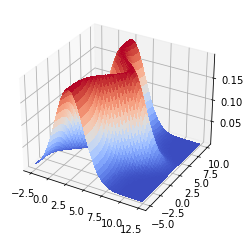

In [4]:
# Plot the surface.
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

surf = ax.plot_surface(X, Y, Z, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

In [50]:
x = np.arange(0, 12.5, 0.1)
y = np.arange(-5, 10, 0.1)
X, Y = np.meshgrid(x, y)

mu = 5
sd = 2
nPRF_func = ss.norm(loc=mu, scale=sd).pdf(x) * 20

Z = []
for i, x_i in enumerate(x):
    mu = nPRF_func[i]
    distr = ss.norm(loc=mu, scale=sd).pdf(y)
    Z.append(distr)

Z = np.array(Z)   

In [60]:
import plotly.graph_objects as go
import plotly.express as px

fig = go.Figure(data=[go.Surface(z=Z.T, y=Y,x=X,surfacecolor = X, colorscale=px.colors.sequential.Rainbow)] )#coloraxis

fig.update_layout(
        scene = {
            "xaxis": {"nticks": 5, "title": "Numerosity"}, # , "backgroundcolor": 'rgba(0,0,0,0)',"showgrid": False
            "yaxis": {"nticks": 2, "title": "Brain activity"},
            "zaxis": {"nticks": 2, "title": "Probability",},
            'camera_eye': {"x": -1, "y": -1, "z": 1},
            "aspectratio": {"x": 1, "y": 1, "z": 0.4}
        }
)
#fig.add_hline(y=0, z=0)
width_line = 4
# z - axis
fig.add_scatter3d(x=np.array([X.min(),X.min()]), y = np.array([0,0]), z = np.array([0,0.3]), mode='lines', line=dict(color='grey', width=width_line)) #,width=2 
# x - axis
fig.add_scatter3d(x=np.array([X.min(),X.max()]), y = np.array([0,0]), z = np.array([Z.max() ,Z.max() ]), mode='lines', line=dict(color='grey', width=width_line)) #,width=2 
# y - axis
fig.add_scatter3d(x=np.array([X.min(),X.min()]), y = np.array([Y.min(),Y.max()]), z = np.array([Z.max() ,Z.max() ]), mode='lines', line=dict(color='grey', width=width_line)) #,width=2 
# curve
fig.add_scatter3d(x=x, y = nPRF_func, z = np.full((len(x),), Z.max()+0.001), mode='lines', line=dict(color='black', width=width_line + 2)) #,width=2 

#fig.update_traces(opacity=0.9, selector=dict(type='surface'))
fig.show()

In [61]:
import plotly.io as py

py.write_image(fig, '/Users/mrenke/Desktop/StressRisk/figures/plots/prob_surface_encoding_model.pdf')